In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt


mat = scipy.io.loadmat(r'C:\Users\ahmtb\Desktop\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0005.mat')

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [3]:
import pprint
pprint.pprint(mat['B0005'].dtype)

dtype([('cycle', 'O')])


In [4]:
cycles = mat['B0005'][0][0]['cycle'][0]
print('Toplam döngü sayısı:', len(cycles))
print('İlk döngü tipi:', cycles[0]['type'][0])

Toplam döngü sayısı: 616
İlk döngü tipi: charge


In [5]:
print('İlk döngünün içindekiler:', cycles[0].dtype)

İlk döngünün içindekiler: [('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]


In [6]:
print('Data içindekiler:', cycles[0]['data'][0][0].dtype)

Data içindekiler: [('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')]


Charge veri sayısı: 789


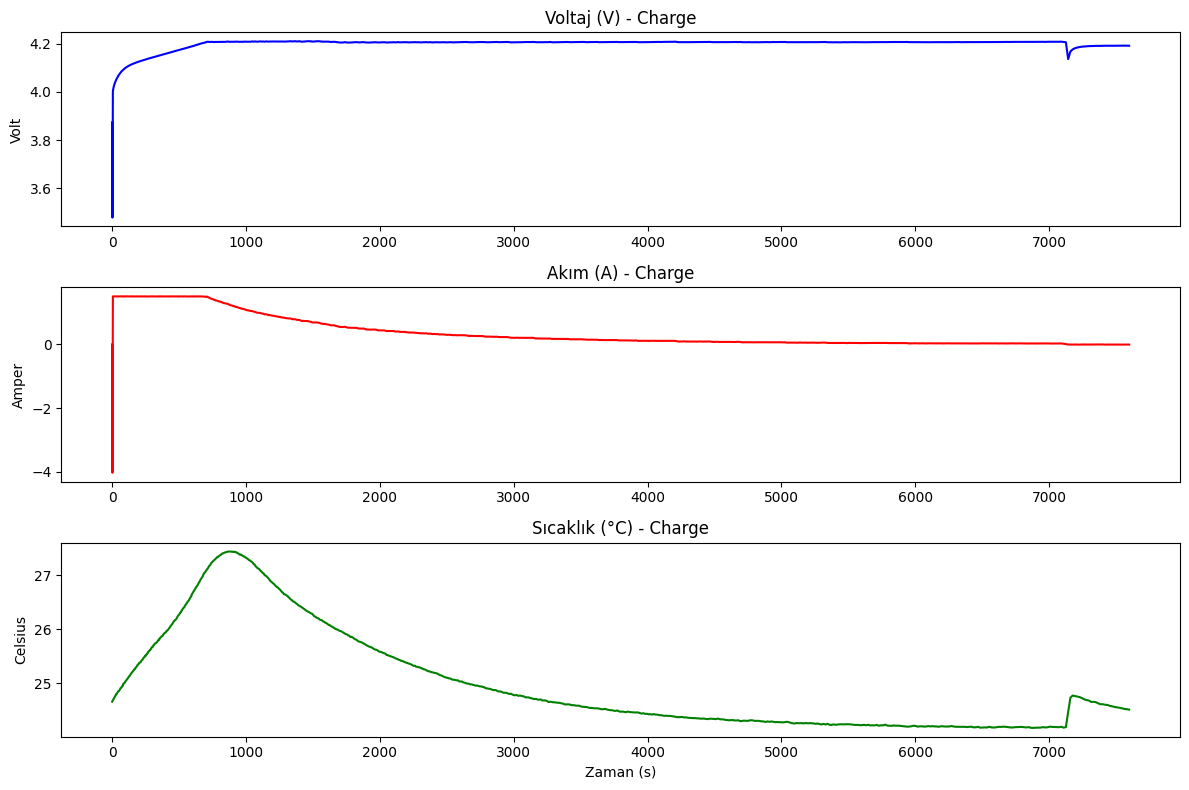

In [7]:

data_charge = cycles[0]['data'][0][0]

voltage_c = data_charge['Voltage_measured'][0].flatten()
current_c = data_charge['Current_measured'][0].flatten()
temperature_c = data_charge['Temperature_measured'][0].flatten()
time_c = data_charge['Time'][0].flatten()

print('Charge veri sayısı:', len(voltage_c))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(time_c, voltage_c, color='blue')
axes[0].set_title('Voltaj (V) - Charge')
axes[0].set_ylabel('Volt')

axes[1].plot(time_c, current_c, color='red')
axes[1].set_title('Akım (A) - Charge')
axes[1].set_ylabel('Amper')

axes[2].plot(time_c, temperature_c, color='green')
axes[2].set_title('Sıcaklık (°C) - Charge')
axes[2].set_ylabel('Celsius')
axes[2].set_xlabel('Zaman (s)')

plt.tight_layout()
plt.show()

Veri sayısı: 197


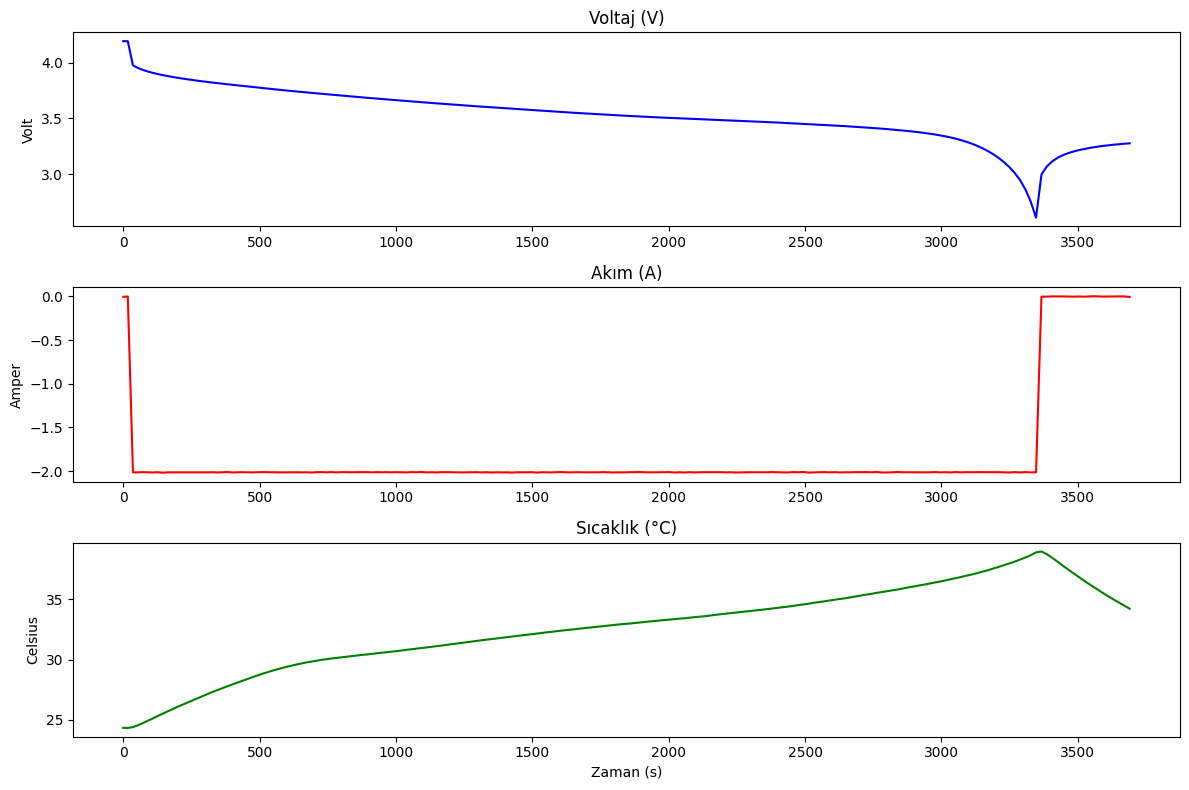

In [8]:
data = cycles[1]['data'][0][0]

voltage = data['Voltage_measured'][0].flatten()
current = data['Current_measured'][0].flatten()
temperature = data['Temperature_measured'][0].flatten()
time = data['Time'][0].flatten()

print('Veri sayısı:', len(voltage))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(time, voltage, color='blue')
axes[0].set_title('Voltaj (V)')
axes[0].set_ylabel('Volt')

axes[1].plot(time, current, color='red')
axes[1].set_title('Akım (A)')
axes[1].set_ylabel('Amper')

axes[2].plot(time, temperature, color='green')
axes[2].set_title('Sıcaklık (°C)')
axes[2].set_ylabel('Celsius')
axes[2].set_xlabel('Zaman (s)')

plt.tight_layout()
plt.show()

Toplam discharge döngüsü: 168
İlk kapasite: 1.8622 Ah
Son kapasite: 1.3279 Ah
Son SOH: %71.3


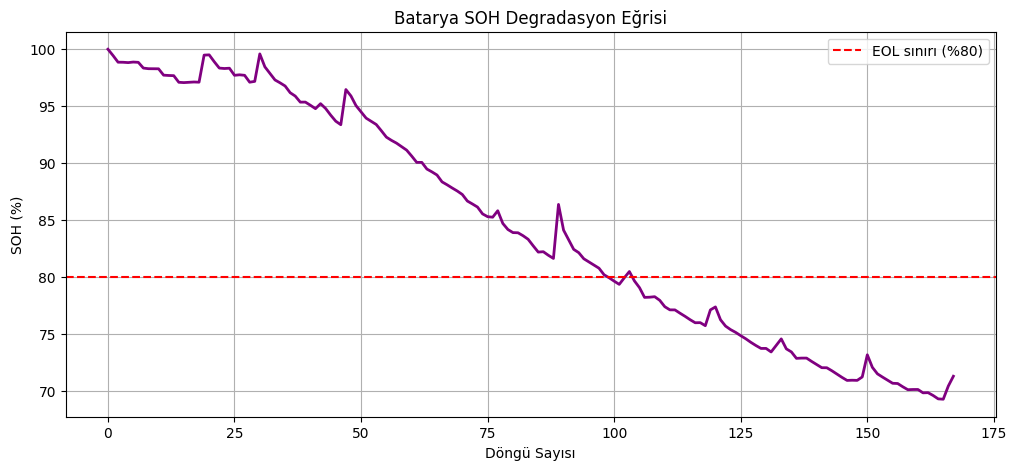

In [9]:
capacities = []
cycle_numbers = []

for i, cycle in enumerate(cycles):
    if cycle['type'][0] == 'discharge':
        data = cycle['data'][0][0]
        current = data['Current_measured'][0].flatten()
        time = data['Time'][0].flatten()
        
        
        capacity = abs(np.trapezoid(current, time)) / 3600
        capacities.append(capacity)
        cycle_numbers.append(i)

capacities = np.array(capacities)
cycle_numbers = np.array(cycle_numbers)


soh = (capacities / capacities[0]) * 100

print(f'Toplam discharge döngüsü: {len(capacities)}')
print(f'İlk kapasite: {capacities[0]:.4f} Ah')
print(f'Son kapasite: {capacities[-1]:.4f} Ah')
print(f'Son SOH: %{soh[-1]:.1f}')


plt.figure(figsize=(12, 5))
plt.plot(range(len(soh)), soh, color='purple', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='EOL sınırı (%80)')
plt.title('Batarya SOH Degradasyon Eğrisi')
plt.xlabel('Döngü Sayısı')
plt.ylabel('SOH (%)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:

battery_files = {
    'B0005': r'C:\Users\ahmtb\Desktop\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0005.mat',
    'B0006': r'C:\Users\ahmtb\Desktop\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0006.mat',
    'B0007': r'C:\Users\ahmtb\Desktop\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0007.mat',
    'B0018': r'C:\Users\ahmtb\Desktop\5. Battery Data Set\1. BatteryAgingARC-FY08Q4\B0018.mat',
}

batteries = {}
for name, path in battery_files.items():
    mat = scipy.io.loadmat(path)
    batteries[name] = mat[name][0][0]['cycle'][0]
    print(f'{name} yüklendi — {len(batteries[name])} döngü')

B0005 yüklendi — 616 döngü
B0006 yüklendi — 616 döngü
B0007 yüklendi — 616 döngü
B0018 yüklendi — 319 döngü


In [11]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()
soh_normalized = scaler.fit_transform(soh.reshape(-1, 1)).flatten()


def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 10  

X, y = create_sequences(soh_normalized, SEQ_LENGTH)


split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


X_train = X_train.reshape(-1, SEQ_LENGTH, 1)
X_test = X_test.reshape(-1, SEQ_LENGTH, 1)

print(f'Train boyutu: {X_train.shape}')
print(f'Test boyutu: {X_test.shape}')
print('Veri hazır! ✅')

Train boyutu: (126, 10, 1)
Test boyutu: (32, 10, 1)
Veri hazır! ✅


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(SEQ_LENGTH, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.3616 - mae: 0.5374 - val_loss: 0.0016 - val_mae: 0.0319
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2234 - mae: 0.4097 - val_loss: 0.0031 - val_mae: 0.0497
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0512 - mae: 0.1736 - val_loss: 0.0416 - val_mae: 0.2027
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0396 - mae: 0.1702 - val_loss: 0.0442 - val_mae: 0.2089
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0239 - mae: 0.1277 - val_loss: 0.0174 - val_mae: 0.1300
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0233 - mae: 0.1177 - val_loss: 0.0159 - val_mae: 0.1241
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - mae: 0.0998 - val_loss: 0.0145 - val_mae: 0.1184
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0103 - mae: 0.0831 - val_loss: 0.0075 - val_mae: 0.0836
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0128 - mae: 

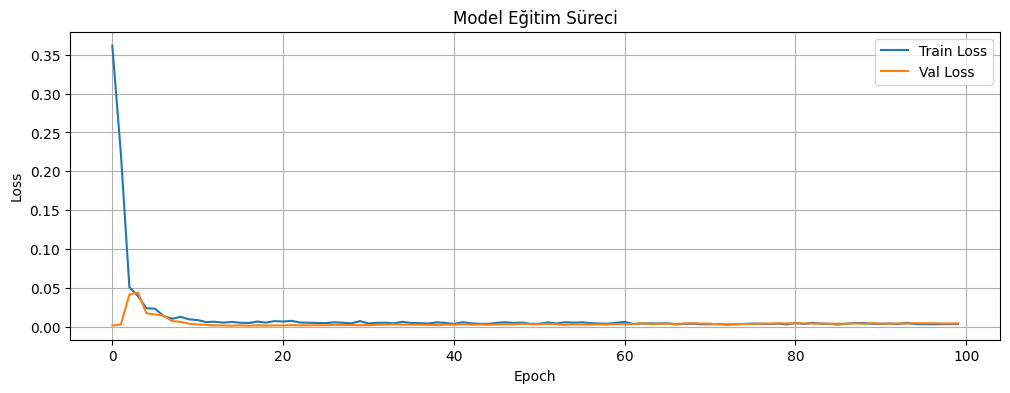

In [13]:

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)


plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
MAE:  0.7386%
RMSE: 0.8197%


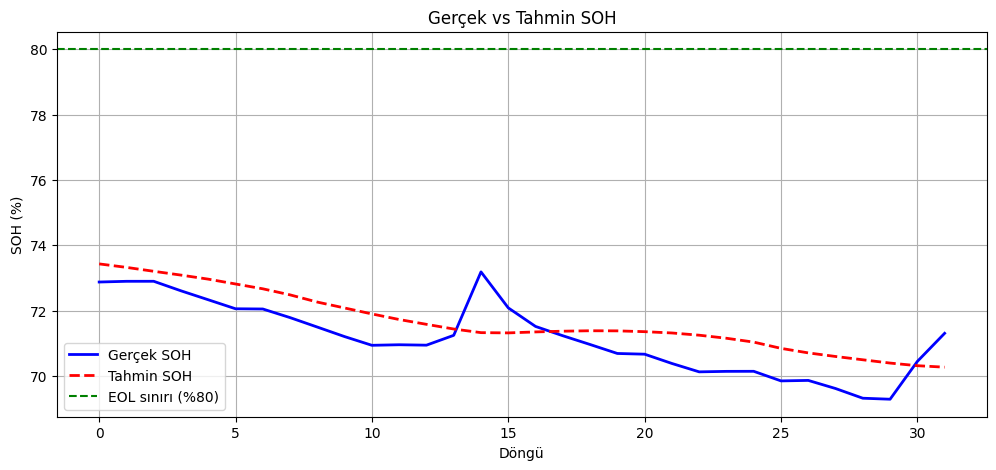

In [15]:

y_pred = model.predict(X_test)


y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred).flatten()


mae = np.mean(np.abs(y_test_real - y_pred_real))
rmse = np.sqrt(np.mean((y_test_real - y_pred_real)**2))

print(f'MAE:  {mae:.4f}%')
print(f'RMSE: {rmse:.4f}%')


plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label='Gerçek SOH', color='blue', linewidth=2)
plt.plot(y_pred_real, label='Tahmin SOH', color='red', linestyle='--', linewidth=2)
plt.axhline(y=80, color='green', linestyle='--', label='EOL sınırı (%80)')
plt.title('Gerçek vs Tahmin SOH')
plt.xlabel('Döngü')
plt.ylabel('SOH (%)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:

model.save('batarya_soh_model.keras')


import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model kaydedildi! ✅')
print('Scaler kaydedildi! ✅')

Model kaydedildi! ✅
Scaler kaydedildi! ✅


In [17]:
!C:\Users\ahmtb\AppData\Local\Programs\Python\Python311\python.exe -m pip install fastapi uvicorn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


B0005 — 168 discharge döngüsü — Son SOH: %71.3
B0006 — 168 discharge döngüsü — Son SOH: %58.9
B0007 — 168 discharge döngüsü — Son SOH: %75.9
B0018 — 132 discharge döngüsü — Son SOH: %72.8


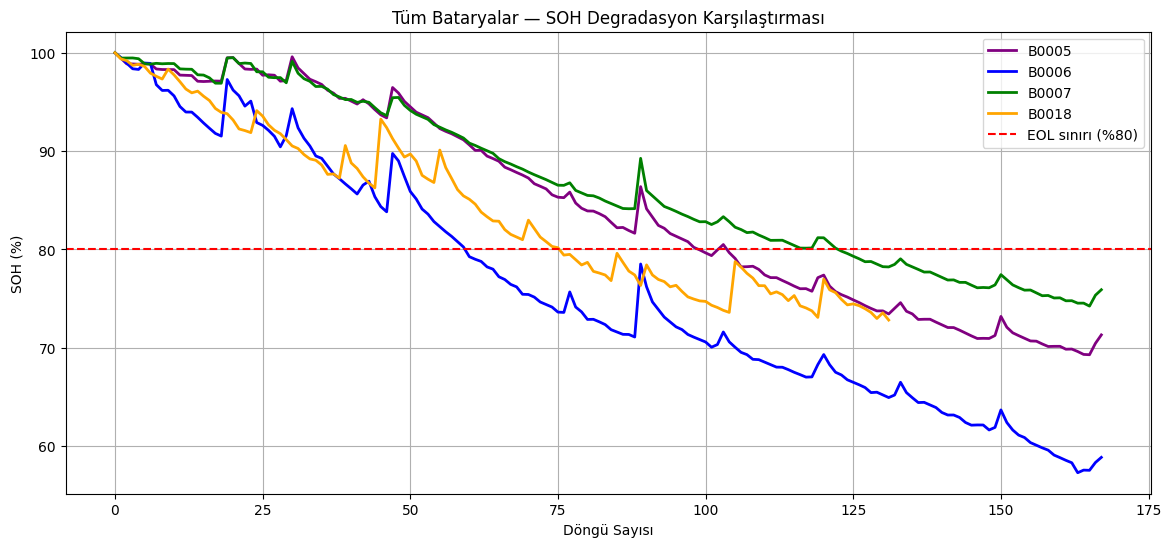

In [18]:
def get_soh(cycles):
    capacities = []
    for cycle in cycles:
        if cycle['type'][0] == 'discharge':
            data = cycle['data'][0][0]
            current = data['Current_measured'][0].flatten()
            time = data['Time'][0].flatten()
            capacity = abs(np.trapezoid(current, time)) / 3600
            capacities.append(capacity)
    capacities = np.array(capacities)
    soh = (capacities / capacities[0]) * 100
    return soh


soh_dict = {}
for name, cycles in batteries.items():
    soh_dict[name] = get_soh(cycles)
    print(f'{name} — {len(soh_dict[name])} discharge döngüsü — Son SOH: %{soh_dict[name][-1]:.1f}')


plt.figure(figsize=(14, 6))
colors = {'B0005': 'purple', 'B0006': 'blue', 'B0007': 'green', 'B0018': 'orange'}

for name, soh in soh_dict.items():
    plt.plot(range(len(soh)), soh, label=name, color=colors[name], linewidth=2)

plt.axhline(y=80, color='red', linestyle='--', label='EOL sınırı (%80)')
plt.title('Tüm Bataryalar — SOH Degradasyon Karşılaştırması')
plt.xlabel('Döngü Sayısı')
plt.ylabel('SOH (%)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:

all_soh = np.concatenate([soh_dict['B0005'], soh_dict['B0006'], 
                          soh_dict['B0007'], soh_dict['B0018']])

print(f'Toplam veri noktası: {len(all_soh)}')


scaler_all = MinMaxScaler()
all_soh_normalized = scaler_all.fit_transform(all_soh.reshape(-1, 1)).flatten()


X_all, y_all = create_sequences(all_soh_normalized, SEQ_LENGTH)


split = int(len(X_all) * 0.8)
X_train_all, X_test_all = X_all[:split], X_all[split:]
y_train_all, y_test_all = y_all[:split], y_all[split:]

X_train_all = X_train_all.reshape(-1, SEQ_LENGTH, 1)
X_test_all = X_test_all.reshape(-1, SEQ_LENGTH, 1)

print(f'Train: {X_train_all.shape}')
print(f'Test: {X_test_all.shape}')

Toplam veri noktası: 636
Train: (500, 10, 1)
Test: (126, 10, 1)


Epoch 1/100


c:\Users\ahmtb\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1376 - mae: 0.2822 - val_loss: 0.0051 - val_mae: 0.0547
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0273 - mae: 0.1179 - val_loss: 0.0031 - val_mae: 0.0425
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0222 - mae: 0.0979 - val_loss: 0.0024 - val_mae: 0.0341
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0214 - mae: 0.0920 - val_loss: 0.0020 - val_mae: 0.0347
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0205 - mae: 0.0890 - val_loss: 0.0022 - val_mae: 0.0389
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190 - mae: 0.0845 - val_loss: 0.0017 - val_mae: 0.0289
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0183 - mae: 0.0809 - val_loss: 0.0017 - val_mae: 0.0345
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.0780 - val_loss: 0.0033 - val_mae: 0.0525
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0177 - mae: 0.

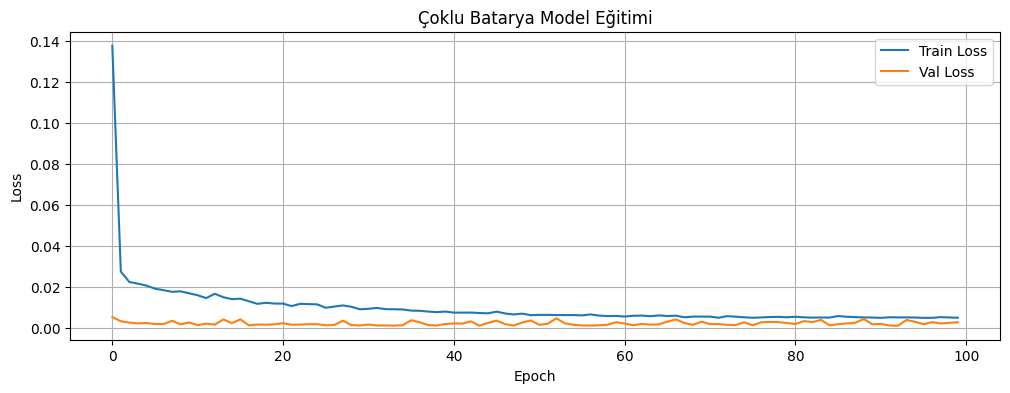

In [20]:

model_all = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_all.compile(optimizer='adam', loss='mse', metrics=['mae'])


history_all = model_all.fit(
    X_train_all, y_train_all,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_all, y_test_all),
    verbose=1
)


plt.figure(figsize=(12, 4))
plt.plot(history_all.history['loss'], label='Train Loss')
plt.plot(history_all.history['val_loss'], label='Val Loss')
plt.title('Çoklu Batarya Model Eğitimi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Çoklu Batarya MAE:  1.5824%
Çoklu Batarya RMSE: 2.1786%
Önceki MAE:  0.5823%
Önceki RMSE: 0.7512%


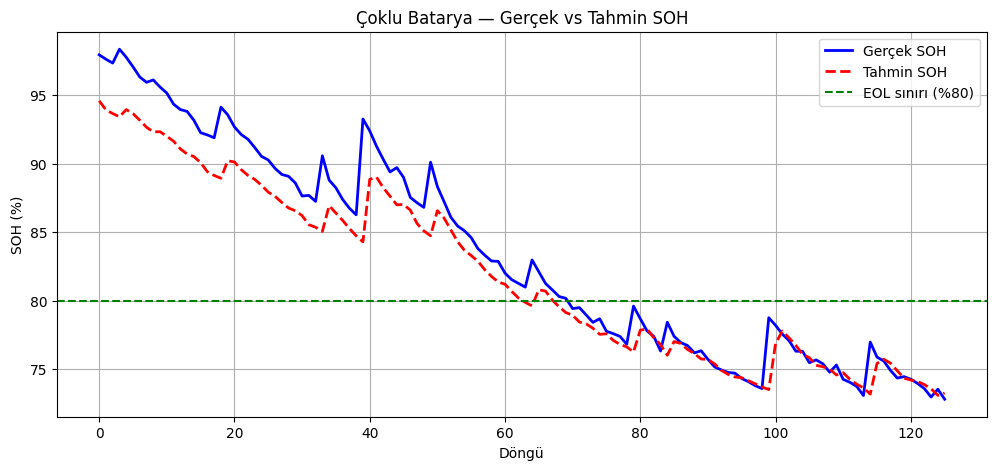

Yeni model kaydedildi! ✅


In [21]:

y_pred_all = model_all.predict(X_test_all)


y_test_real_all = scaler_all.inverse_transform(y_test_all.reshape(-1, 1)).flatten()
y_pred_real_all = scaler_all.inverse_transform(y_pred_all).flatten()


mae_all = np.mean(np.abs(y_test_real_all - y_pred_real_all))
rmse_all = np.sqrt(np.mean((y_test_real_all - y_pred_real_all)**2))

print(f'Çoklu Batarya MAE:  {mae_all:.4f}%')
print(f'Çoklu Batarya RMSE: {rmse_all:.4f}%')
print(f'Önceki MAE:  0.5823%')
print(f'Önceki RMSE: 0.7512%')


plt.figure(figsize=(12, 5))
plt.plot(y_test_real_all, label='Gerçek SOH', color='blue', linewidth=2)
plt.plot(y_pred_real_all, label='Tahmin SOH', color='red', linestyle='--', linewidth=2)
plt.axhline(y=80, color='green', linestyle='--', label='EOL sınırı (%80)')
plt.title('Çoklu Batarya — Gerçek vs Tahmin SOH')
plt.xlabel('Döngü')
plt.ylabel('SOH (%)')
plt.legend()
plt.grid(True)
plt.show()


model_all.save('batarya_soh_model.keras')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_all, f)

print('Yeni model kaydedildi! ✅')

B0005 — Başlangıç RUL: 99 döngü
B0006 — Başlangıç RUL: 60 döngü
B0007 — Başlangıç RUL: 123 döngü
B0018 — Başlangıç RUL: 76 döngü


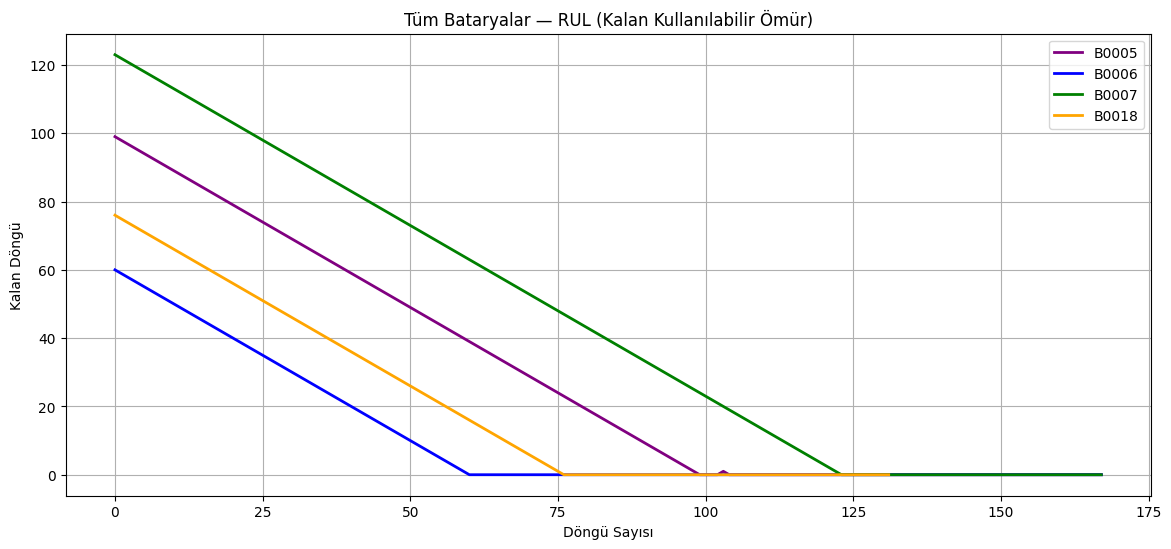

In [22]:

def get_rul(soh, eol_threshold=80):
    rul = []
    for i in range(len(soh)):
        
        remaining = np.where(soh[i:] < eol_threshold)[0]
        if len(remaining) > 0:
            rul.append(remaining[0])
        else:
            rul.append(len(soh) - i)  
    return np.array(rul)


plt.figure(figsize=(14, 6))
colors = {'B0005': 'purple', 'B0006': 'blue', 'B0007': 'green', 'B0018': 'orange'}

for name, soh in soh_dict.items():
    rul = get_rul(soh)
    plt.plot(range(len(rul)), rul, label=name, color=colors[name], linewidth=2)
    print(f'{name} — Başlangıç RUL: {rul[0]} döngü')

plt.title('Tüm Bataryalar — RUL (Kalan Kullanılabilir Ömür)')
plt.xlabel('Döngü Sayısı')
plt.ylabel('Kalan Döngü')
plt.legend()
plt.grid(True)
plt.show()